# Regressão com PyTorch — California Housing

## Objetivos da aula

1. Construir um **Dataset customizado** a partir de dados tabulares.
2. Treinar uma rede neural para **regressão** (prever preços de imóveis).
3. Usar a interface web do **TensorBoard** para acompanhar o treino.
4. **Salvar** e **carregar** o melhor modelo (persistência).

**Dataset:** California Housing (scikit-learn) — 20.640 amostras, 8 features numéricas, alvo contínuo (preço mediano em $100k).

## 1. Importando as bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

Usando device: cpu


## 2. Carregando os dados

Cada amostra descreve um bloco de casas na Califórnia. Features incluem renda mediana, idade das casas, número médio de cômodos, latitude, longitude, etc. O alvo é o preço mediano em centenas de milhares de dólares.

In [3]:
dados = fetch_california_housing()
X, y = dados.data, dados.target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {dados.feature_names}")
print(f"y min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")

# Padronização das features (muito importante para redes neurais)
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

# Padronizar o target também ajuda na convergência
scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1,1)).flatten()

X shape: (20640, 8)
y shape: (20640,)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
y min=0.15, max=5.00, mean=2.07


## 3. Dataset customizado

Observe que aqui o **target é float** (contínuo), diferente da classificação.

In [4]:
class HousingDataset(Dataset):
    """Dataset para regressão tabular."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = HousingDataset(X, y)
print(f"Tamanho: {len(dataset)}")
xi, yi = dataset[0]
print(f"Exemplo 0: X={xi.shape}, y={yi.item():.4f}")

Tamanho: 20640
Exemplo 0: X=torch.Size([8]), y=2.1296


## 4. DataLoader com split 70/15/15

In [5]:
n_total  = len(dataset)
n_treino = int(0.70 * n_total)
n_val    = int(0.15 * n_total)
n_teste  = n_total - n_treino - n_val

treino_ds, val_ds, teste_ds = random_split(
    dataset, [n_treino, n_val, n_teste],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH = 64
train_loader = DataLoader(treino_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,    batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(teste_ds,  batch_size=BATCH, shuffle=False)

print(f"Treino: {len(treino_ds)} | Val: {len(val_ds)} | Teste: {len(teste_ds)}")

Xb, yb = next(iter(train_loader))
print(f"Batch X: {Xb.shape}, y: {yb.shape}")

Treino: 14447 | Val: 3096 | Teste: 3097
Batch X: torch.Size([64, 8]), y: torch.Size([64])


## 5. Modelo de regressão

A última camada tem **1 neurônio linear** (sem ativação) porque queremos um número real.

In [6]:
class Regressor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)   # saída contínua
        )

    def forward(self, x):
        return self.rede(x).squeeze(-1)  # remove a dim extra


modelo = Regressor(n_features=X.shape[1]).to(device)
print(modelo)
print(f"\nParâmetros: {sum(p.numel() for p in modelo.parameters()):,}")

Regressor(
  (rede): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=16, bias=True)
    (6): ReLU()
    (7): Linear(in_features=16, out_features=1, bias=True)
  )
)

Parâmetros: 3,201


## 6. Loss, otimizador e TensorBoard

- **MSELoss** (erro quadrático médio) para regressão.
- Adam como otimizador.
- Schedule que reduz o LR quando a validação estagnar.

In [7]:
criterio  = nn.MSELoss()
optimizer = optim.Adam(modelo.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

writer = SummaryWriter(log_dir="runs/regressao_california")

## 7. Loop de treino e avaliação

In [10]:
def treinar_epoca(modelo, loader, criterio, optimizer, device):
    modelo.train()
    loss_total, total = 0.0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = modelo(Xb)
        loss = criterio(pred, yb)
        loss.backward()
        optimizer.step()
        loss_total += loss.item() * Xb.size(0)
        total      += Xb.size(0)
    return loss_total/total


def avaliar(modelo, loader, criterio, device):
    modelo.eval()
    loss_total, total = 0.0, 0
    all_pred, all_y = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = modelo(Xb)
            loss = criterio(pred, yb)
            loss_total += loss.item() * Xb.size(0)
            total      += Xb.size(0)
            all_pred.append(pred.cpu().numpy())
            all_y.append(yb.cpu().numpy())
    return (loss_total/total,
            np.concatenate(all_pred),
            np.concatenate(all_y))

In [11]:
N_EPOCAS = 60
historico = {"train_loss": [], "val_loss": [], "val_r2": [], "val_mae": []}
melhor_val_loss = float("inf")

for epoca in range(1, N_EPOCAS + 1):
    tr_loss = treinar_epoca(modelo, train_loader, criterio, optimizer, device)
    vl_loss, pred_val, y_val = avaliar(modelo, val_loader, criterio, device)

    # Desfazer a padronização do target para calcular métricas na escala real
    pred_real = scaler_y.inverse_transform(pred_val.reshape(-1,1)).flatten()
    y_real    = scaler_y.inverse_transform(y_val.reshape(-1,1)).flatten()
    r2  = r2_score(y_real, pred_real)
    mae = mean_absolute_error(y_real, pred_real)

    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["val_r2"].append(r2)
    historico["val_mae"].append(mae)

    scheduler.step(vl_loss)

    # TensorBoard
    writer.add_scalars("Loss_MSE", {"treino": tr_loss, "val": vl_loss}, epoca)
    writer.add_scalar("R2/val", r2, epoca)
    writer.add_scalar("MAE/val", mae, epoca)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoca)

    # Persistência do melhor modelo
    if vl_loss < melhor_val_loss:
        melhor_val_loss = vl_loss
        torch.save({
            "epoca": epoca,
            "modelo_state": modelo.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": vl_loss,
            "val_r2": r2,
        }, "melhor_regressor.pth")

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:02d} | treino={tr_loss:.4f} | val={vl_loss:.4f} "
              f"| R²={r2:.4f} | MAE=${mae*100:.2f}k")

writer.close()
print("\nTreinamento concluído!")

Época 01 | treino=0.5936 | val=0.3596 | R²=0.6312 | MAE=$48.63k
Época 05 | treino=0.3024 | val=0.2626 | R²=0.7307 | MAE=$42.43k
Época 10 | treino=0.2652 | val=0.2436 | R²=0.7502 | MAE=$39.58k
Época 15 | treino=0.2505 | val=0.2351 | R²=0.7588 | MAE=$37.83k
Época 20 | treino=0.2416 | val=0.2395 | R²=0.7543 | MAE=$38.14k
Época 25 | treino=0.2333 | val=0.2202 | R²=0.7742 | MAE=$36.61k
Época 30 | treino=0.2287 | val=0.2128 | R²=0.7817 | MAE=$35.86k
Época 35 | treino=0.2213 | val=0.2111 | R²=0.7834 | MAE=$35.21k
Época 40 | treino=0.2176 | val=0.2149 | R²=0.7795 | MAE=$35.82k
Época 45 | treino=0.2123 | val=0.2097 | R²=0.7849 | MAE=$35.21k
Época 50 | treino=0.2105 | val=0.2022 | R²=0.7925 | MAE=$35.03k
Época 55 | treino=0.2057 | val=0.2101 | R²=0.7845 | MAE=$34.70k
Época 60 | treino=0.1990 | val=0.2000 | R²=0.7948 | MAE=$34.48k

Treinamento concluído!


## 8. Gráficos do treinamento

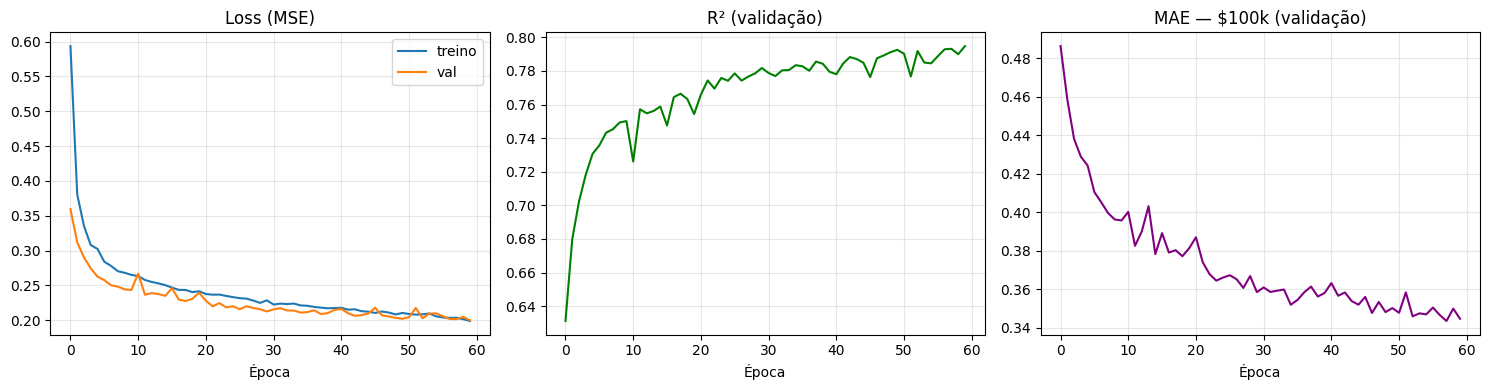

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(historico["train_loss"], label="treino")
axes[0].plot(historico["val_loss"], label="val")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Época")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(historico["val_r2"], color="green")
axes[1].set_title("R² (validação)")
axes[1].set_xlabel("Época")
axes[1].grid(alpha=0.3)

axes[2].plot(historico["val_mae"], color="purple")
axes[2].set_title("MAE — $100k (validação)")
axes[2].set_xlabel("Época")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Persistência: carregando o melhor modelo

In [13]:
modelo_final = Regressor(n_features=X.shape[1]).to(device)
ckpt = torch.load("melhor_regressor.pth", map_location=device)
modelo_final.load_state_dict(ckpt["modelo_state"])
modelo_final.eval()

print(f"Carregado checkpoint da época {ckpt['epoca']}")
print(f"val_loss: {ckpt['val_loss']:.4f} | val_r2: {ckpt['val_r2']:.4f}")

Carregado checkpoint da época 60
val_loss: 0.2000 | val_r2: 0.7948


## 10. Avaliação final no conjunto de teste

In [14]:
test_loss, pred_test, y_test = avaliar(modelo_final, test_loader, criterio, device)

# Voltar à escala original
pred_real = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
y_real    = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

mse = mean_squared_error(y_real, pred_real)
mae = mean_absolute_error(y_real, pred_real)
r2  = r2_score(y_real, pred_real)

print(f"== TESTE (valores em $100k) ==")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}  (≈ ${np.sqrt(mse)*100:.2f}k)")
print(f"MAE:  {mae:.4f}  (≈ ${mae*100:.2f}k)")
print(f"R²:   {r2:.4f}")

== TESTE (valores em $100k) ==
MSE:  0.2434
RMSE: 0.4934  (≈ $49.34k)
MAE:  0.3378  (≈ $33.78k)
R²:   0.8236


## 11. Visualizando predições vs. valores reais

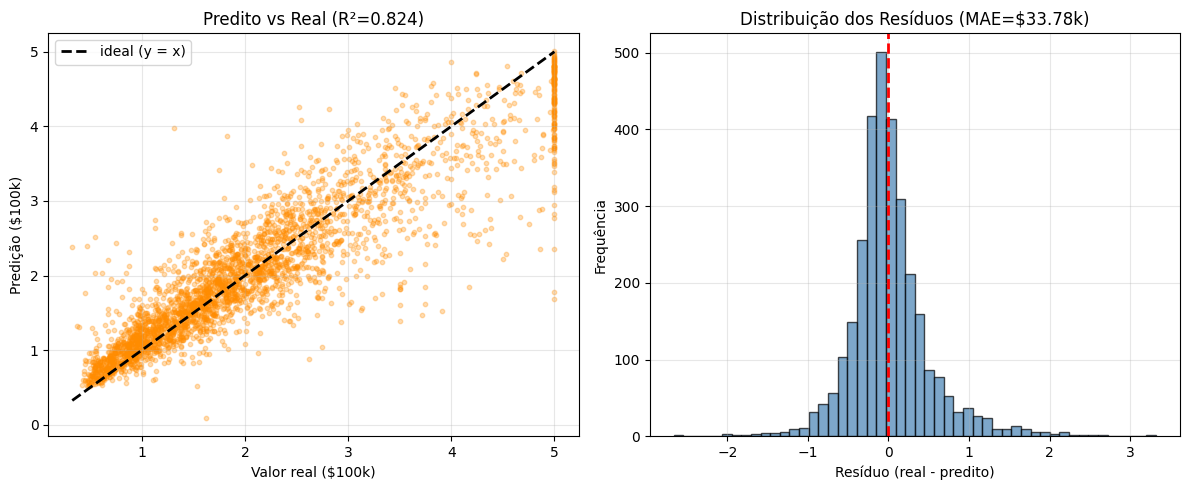

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Scatter: predito vs real
axes[0].scatter(y_real, pred_real, alpha=0.3, s=10, color='darkorange')
lims = [y_real.min(), y_real.max()]
axes[0].plot(lims, lims, 'k--', lw=2, label='ideal (y = x)')
axes[0].set_xlabel('Valor real ($100k)')
axes[0].set_ylabel('Predição ($100k)')
axes[0].set_title(f'Predito vs Real (R²={r2:.3f})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) Histograma dos resíduos
residuos = y_real - pred_real
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Resíduo (real - predito)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos (MAE=${mae*100:.2f}k)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Predição em novas amostras

Fluxo completo: carregar modelo → pré-processar entradas → predizer → desfazer padronização.

In [16]:
# Simulando 3 novas amostras (com os valores originais, antes do scaler)
amostras_originais = np.array([
    # MedInc HouseAge AveRooms AveBedrms Population AveOccup Latitude Longitude
    [8.3252,  41.0,    6.9841,  1.0238,   322.0,    2.5556,  37.88,   -122.23],
    [3.2596,  33.0,    5.0179,  1.0389,  1392.0,    3.5167,  34.10,   -118.30],
    [1.6812,  45.0,    4.1929,  1.1222,   650.0,    2.8947,  36.77,   -119.78],
])

# Aplicar o mesmo scaler usado no treino
amostras_scaled = scaler_X.transform(amostras_originais)
X_novo = torch.tensor(amostras_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    pred_scaled = modelo_final(X_novo).cpu().numpy()

# Voltar à escala original
pred_reais = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

for i, p in enumerate(pred_reais):
    print(f"Amostra {i+1}: preço previsto ≈ ${p*100:.2f}k")

Amostra 1: preço previsto ≈ $392.51k
Amostra 2: preço previsto ≈ $182.50k
Amostra 3: preço previsto ≈ $59.99k


## 13. Abrindo o TensorBoard

No terminal, dentro da pasta do notebook:

```bash
tensorboard --logdir=runs --port=6006
```

Abra **http://localhost:6006** no navegador. Você verá:
- `Loss_MSE/treino` e `Loss_MSE/val` comparadas
- `R2/val` e `MAE/val` em escala real
- `LR` (learning rate) evoluindo com o scheduler

**Dica:** se você treinou os 3 notebooks (binária, CIFAR10 e regressão), vai ver os três experimentos lado a lado — ótimo para comparar.

### Dentro do notebook:
```python
%load_ext tensorboard
%tensorboard --logdir runs
```

## Resumo

- Implementamos um **Dataset customizado** para dados tabulares.
- Construímos um **regressor** (saída linear de 1 neurônio).
- Treinamos com **MSELoss** + scheduler `ReduceLROnPlateau`.
- **Persistimos** o melhor modelo com `torch.save` / `load_state_dict`.
- Avaliamos com **MSE, RMSE, MAE e R²** na escala real.
- Acompanhamos tudo pelo **TensorBoard**.